# **Color Model Conversion**

Convert an image between RGB, HSI, CMY, and CMYK color spaces.

Visualize each channel separately.

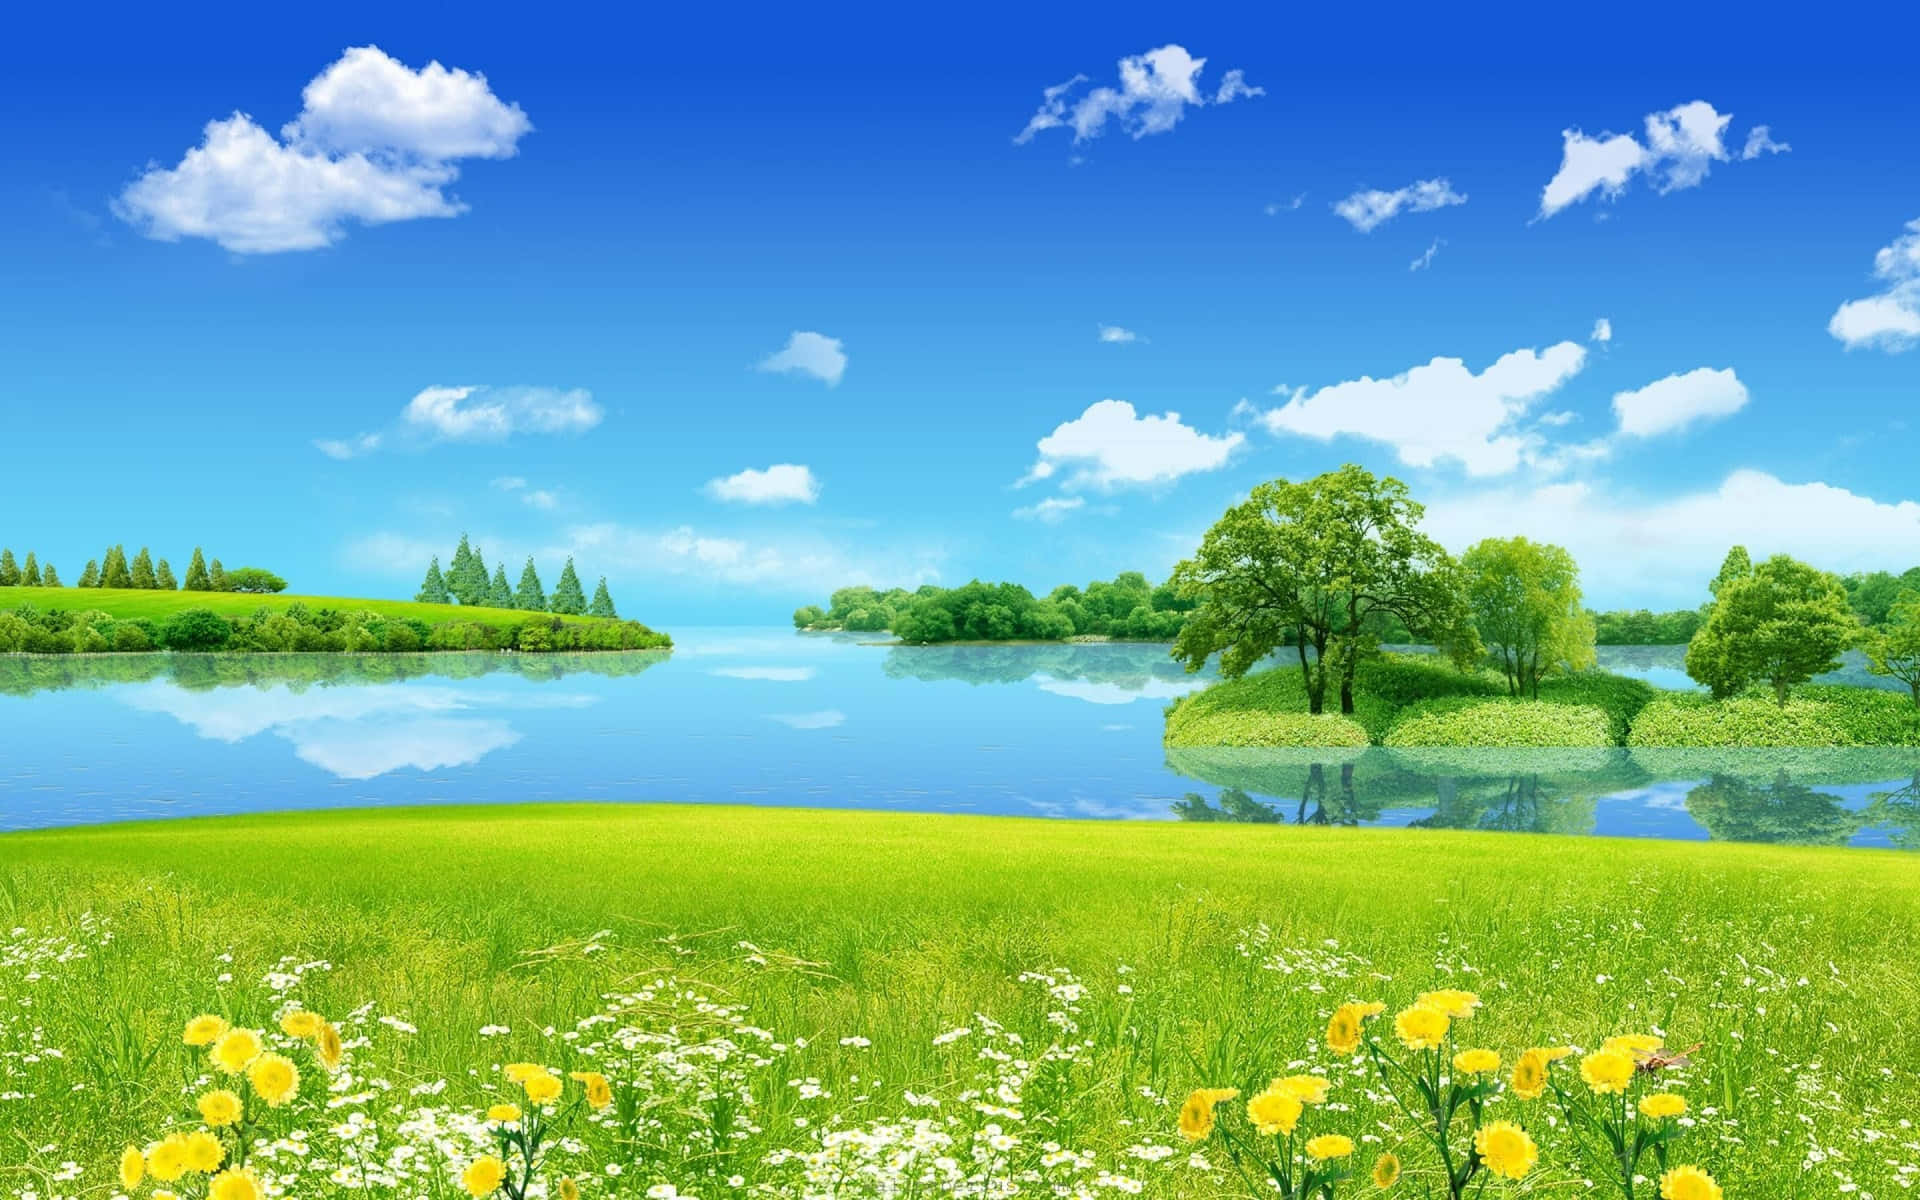

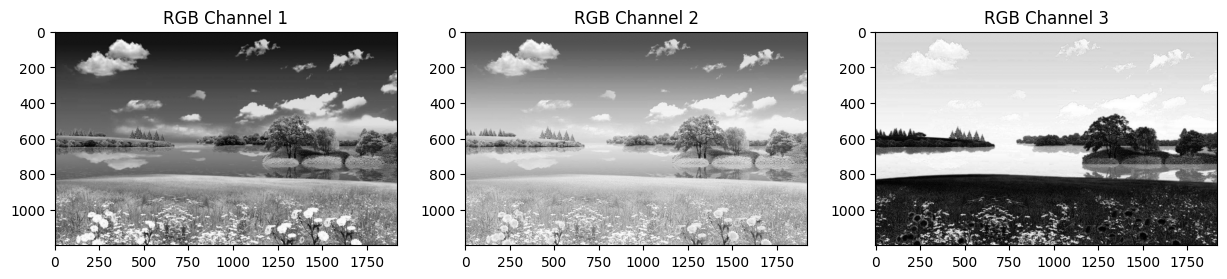

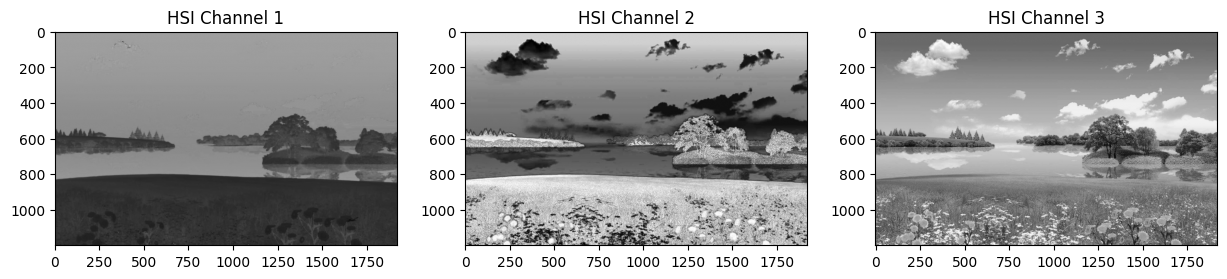

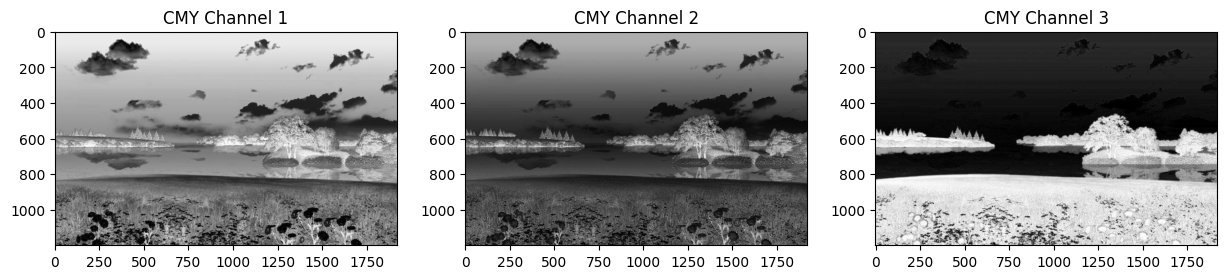

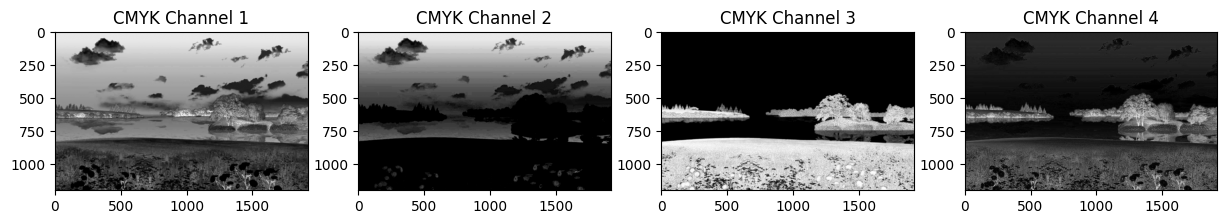

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load an image
image = cv2.imread('color.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

# Function to convert RGB to HSI
def rgb_to_hsi(image):
    image = image.astype('float32') / 255.0
    r, g, b = image[:, :, 0], image[:, :, 1], image[:, :, 2]

    # Calculate Intensity (I)
    I = (r + g + b) / 3.0

    # Calculate Saturation (S)
    min_rgb = np.minimum(np.minimum(r, g), b)
    S = 1 - (3 / (r + g + b + 1e-6)) * min_rgb

    # Calculate Hue (H)
    numerator = 0.5 * ((r - g) + (r - b))
    denominator = np.sqrt((r - g)**2 + (r - b) * (g - b))
    H = np.arccos(numerator / (denominator + 1e-6))
    H[b > g] = 2 * np.pi - H[b > g]
    H = H / (2 * np.pi)

    # Stack HSI channels
    HSI = np.dstack((H, S, I))
    return HSI

# Function to convert RGB to CMY
def rgb_to_cmy(image):
    image = image.astype('float32') / 255.0
    C = 1 - image[:, :, 0]
    M = 1 - image[:, :, 1]
    Y = 1 - image[:, :, 2]
    CMY = np.dstack((C, M, Y))
    return CMY

# Function to convert RGB to CMYK
def rgb_to_cmyk(image):
    image = image.astype('float32') / 255.0
    K = 1 - np.max(image, axis=2)
    C = (1 - image[:, :, 0] - K) / (1 - K + 1e-6)
    M = (1 - image[:, :, 1] - K) / (1 - K + 1e-6)
    Y = (1 - image[:, :, 2] - K) / (1 - K + 1e-6)
    CMYK = np.dstack((C, M, Y, K))
    return CMYK

# Convert the image to different color spaces
hsi_image = rgb_to_hsi(image)
cmy_image = rgb_to_cmy(image)
cmyk_image = rgb_to_cmyk(image)

# Visualize each channel separately
def visualize_channels(image, title):
    channels = image.shape[2]
    plt.figure(figsize=(15, 5))
    for i in range(channels):
        plt.subplot(1, channels, i + 1)
        plt.imshow(image[:, :, i], cmap='gray')
        plt.title(f'{title} Channel {i + 1}')
    plt.show()

# Visualize RGB channels
visualize_channels(image, 'RGB')

# Visualize HSI channels
visualize_channels(hsi_image, 'HSI')

# Visualize CMY channels
visualize_channels(cmy_image, 'CMY')

# Visualize CMYK channels
visualize_channels(cmyk_image, 'CMYK')

# **Histogram Analysis for Color Images**

Plot histograms for R, G, and B channels separately.

Perform histogram equalization to enhance contrast.

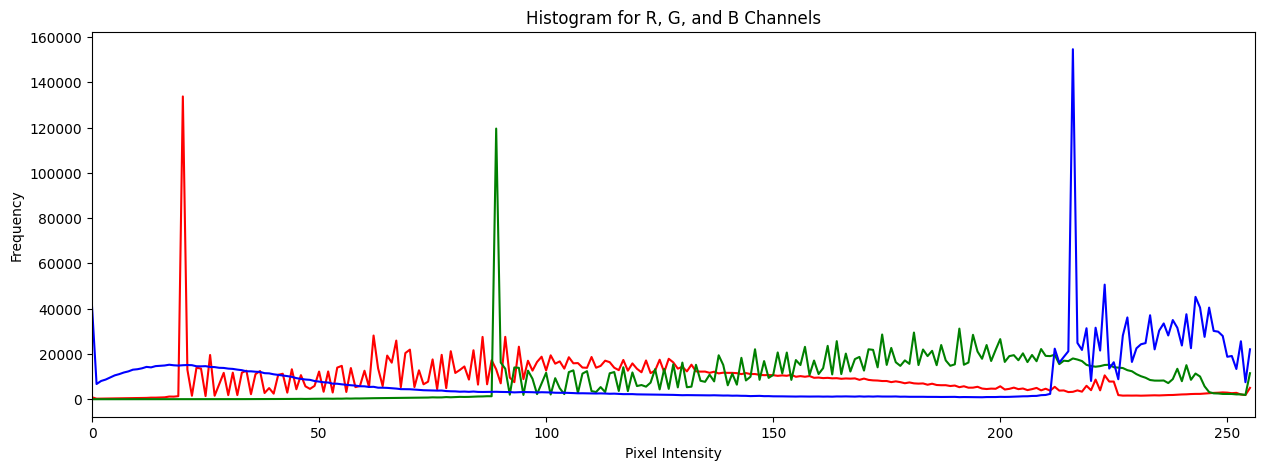

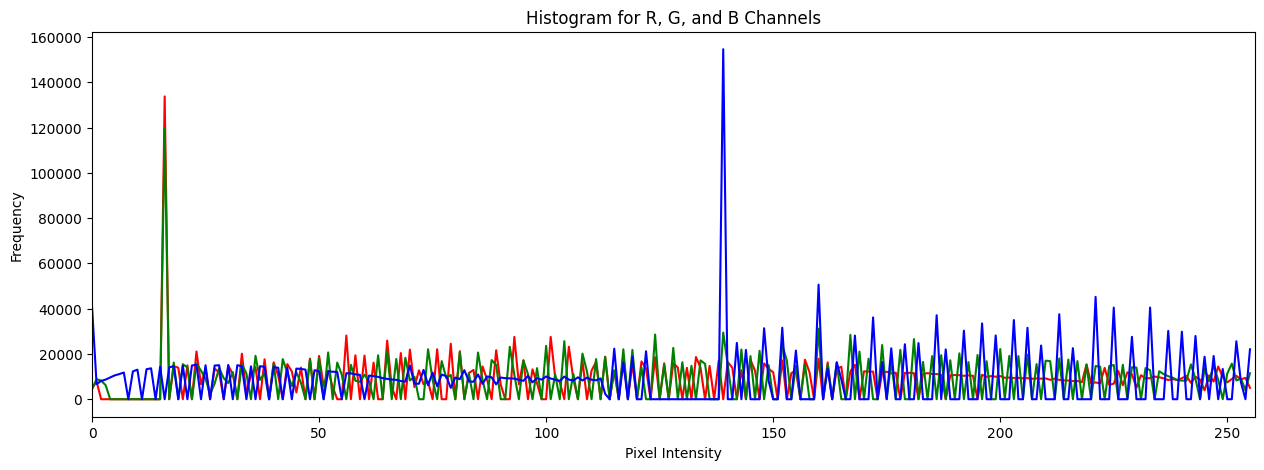

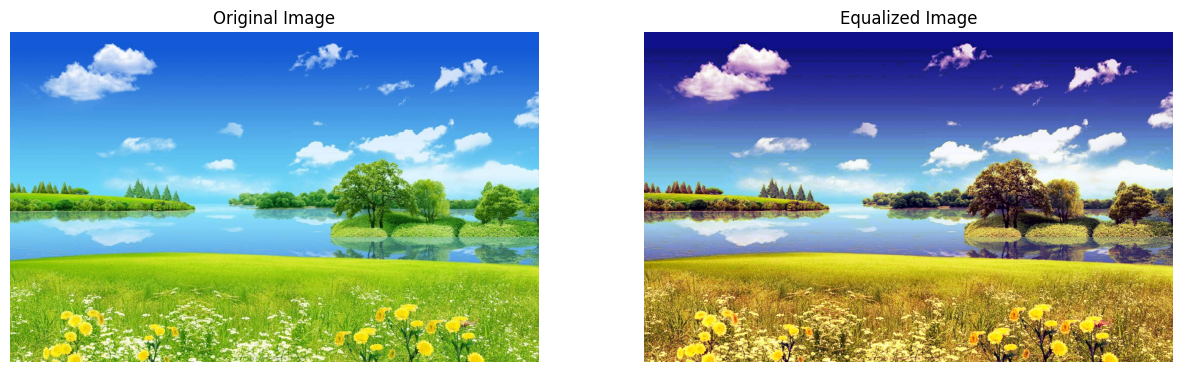

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load an image
image = cv2.imread('color.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

# Plot histograms for R, G, and B channels
def plot_histograms(image):
    colors = ('r', 'g', 'b')
    channel_ids = (0, 1, 2)

    plt.figure(figsize=(15, 5))
    for channel_id, color in zip(channel_ids, colors):
        histogram = cv2.calcHist([image], [channel_id], None, [256], [0, 256])
        plt.plot(histogram, color=color)
        plt.xlim([0, 256])
    plt.title('Histogram for R, G, and B Channels')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.show()

# Perform histogram equalization for each channel
def equalize_histogram(image):
    # Split the image into R, G, and B channels
    r, g, b = cv2.split(image)

    # Apply histogram equalization to each channel
    r_eq = cv2.equalizeHist(r)
    g_eq = cv2.equalizeHist(g)
    b_eq = cv2.equalizeHist(b)

    # Merge the equalized channels back into an RGB image
    equalized_image = cv2.merge((r_eq, g_eq, b_eq))
    return equalized_image

# Plot histograms for the original image
plot_histograms(image)

# Perform histogram equalization
equalized_image = equalize_histogram(image)

# Plot histograms for the equalized image
plot_histograms(equalized_image)

# Display the original and equalized images
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(equalized_image)
plt.title('Equalized Image')
plt.axis('off')

plt.show()

# **Color Image Enhancement**

Adjust brightness, contrast, and gamma correction for a color image.

Apply log transformation and power-law (gamma) transformation to RGB images.

<ipython-input-3-cba36ebf57bd>:32: RuntimeWarning: divide by zero encountered in log
  log_transformed_image = c * (np.log(image + 1))
<ipython-input-3-cba36ebf57bd>:33: RuntimeWarning: invalid value encountered in cast
  log_transformed_image = np.uint8(log_transformed_image)


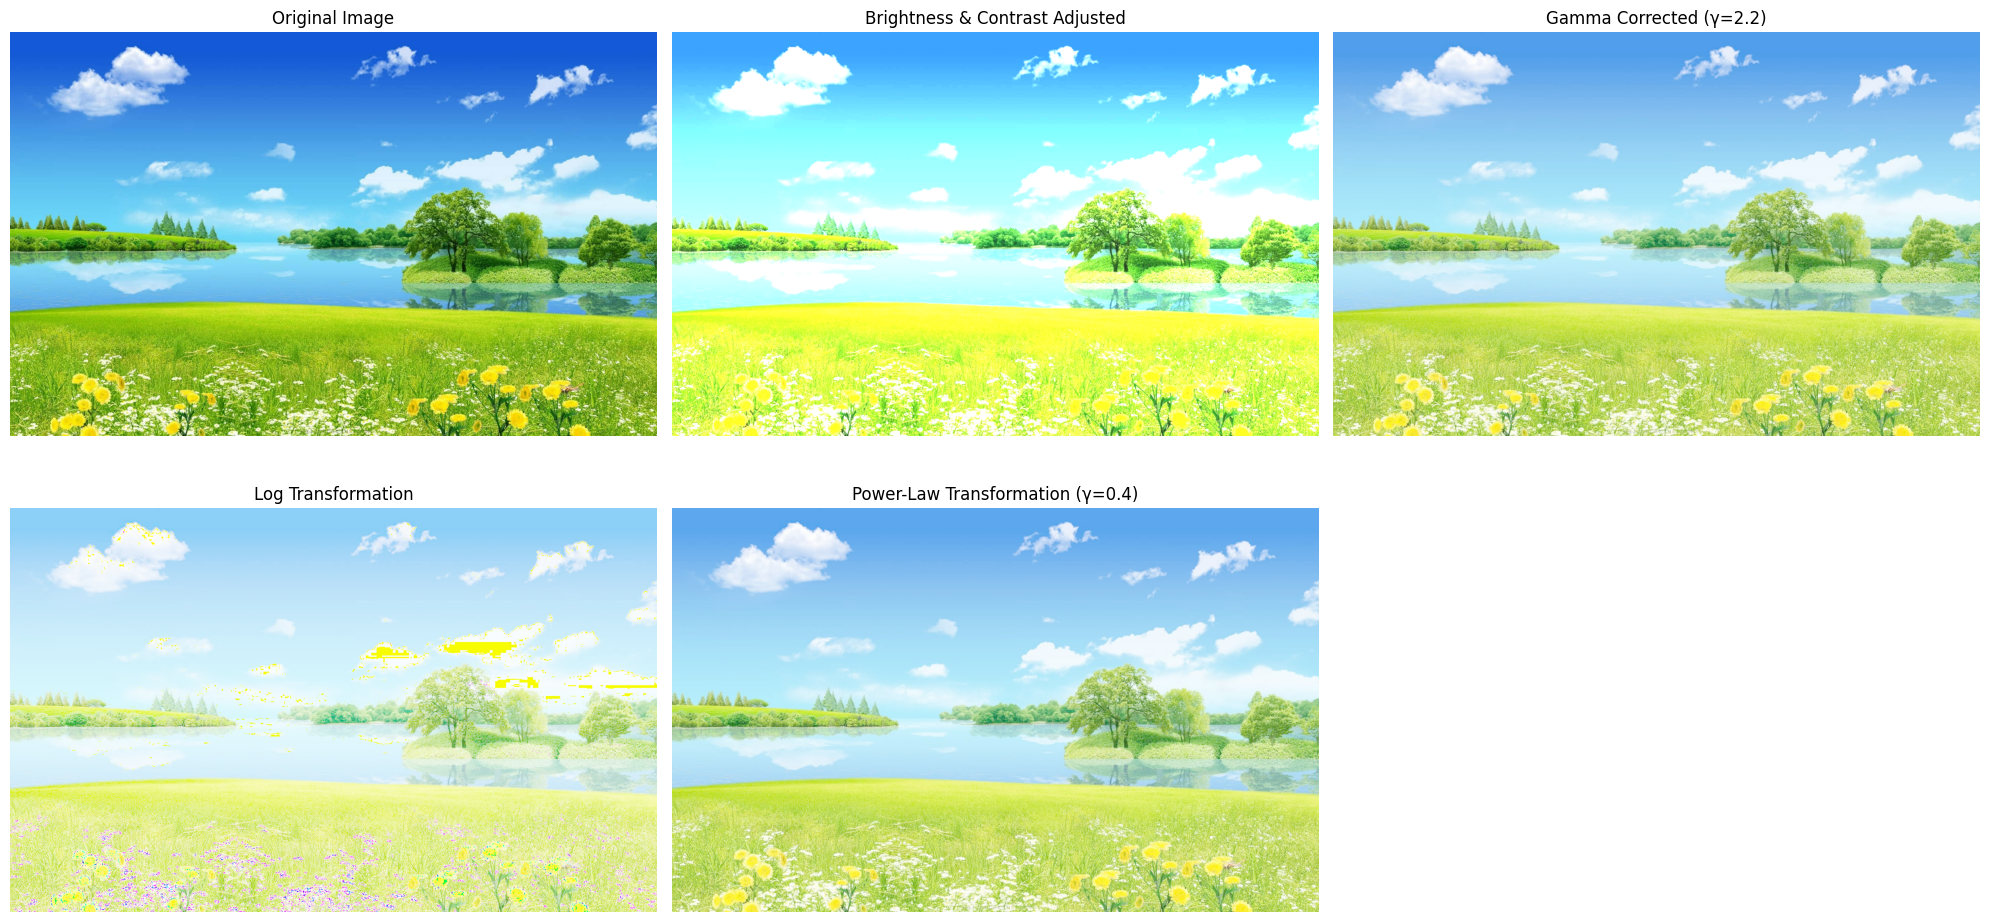

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load an image
image = cv2.imread('color.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

# Function to adjust brightness and contrast
def adjust_brightness_contrast(image, alpha=1.0, beta=0):
    """
    alpha: contrast control (1.0 means no change)
    beta: brightness control (0 means no change)
    """
    adjusted_image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
    return adjusted_image

# Function to apply gamma correction
def gamma_correction(image, gamma=1.0):
    # Build a lookup table mapping the pixel values [0, 255] to their adjusted gamma values
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")

    # Apply gamma correction using the lookup table
    gamma_corrected_image = cv2.LUT(image, table)
    return gamma_corrected_image

# Function to apply log transformation
def log_transformation(image):
    # Normalize the image to the range [0, 1]
    c = 255 / np.log(1 + np.max(image))
    log_transformed_image = c * (np.log(image + 1))
    log_transformed_image = np.uint8(log_transformed_image)
    return log_transformed_image

# Function to apply power-law (gamma) transformation
def power_law_transformation(image, gamma=1.0):
    # Normalize the image to the range [0, 1]
    image_normalized = image / 255.0
    # Apply power-law transformation
    power_law_transformed_image = np.uint8(255 * (image_normalized ** gamma))
    return power_law_transformed_image

# Adjust brightness and contrast
brightness_contrast_adjusted_image = adjust_brightness_contrast(image, alpha=1.5, beta=30)

# Apply gamma correction
gamma_corrected_image = gamma_correction(image, gamma=2.2)

# Apply log transformation
log_transformed_image = log_transformation(image)

# Apply power-law transformation
power_law_transformed_image = power_law_transformation(image, gamma=0.4)

# Display the original and enhanced images
plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(brightness_contrast_adjusted_image)
plt.title('Brightness & Contrast Adjusted')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(gamma_corrected_image)
plt.title('Gamma Corrected (γ=2.2)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(log_transformed_image)
plt.title('Log Transformation')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(power_law_transformed_image)
plt.title('Power-Law Transformation (γ=0.4)')
plt.axis('off')

plt.tight_layout()
plt.show()

# **HSI Manipulation**

Convert RGB to HSI/HSV and manipulate hue, saturation, and intensity components.

Convert back to RGB and observe the effects.

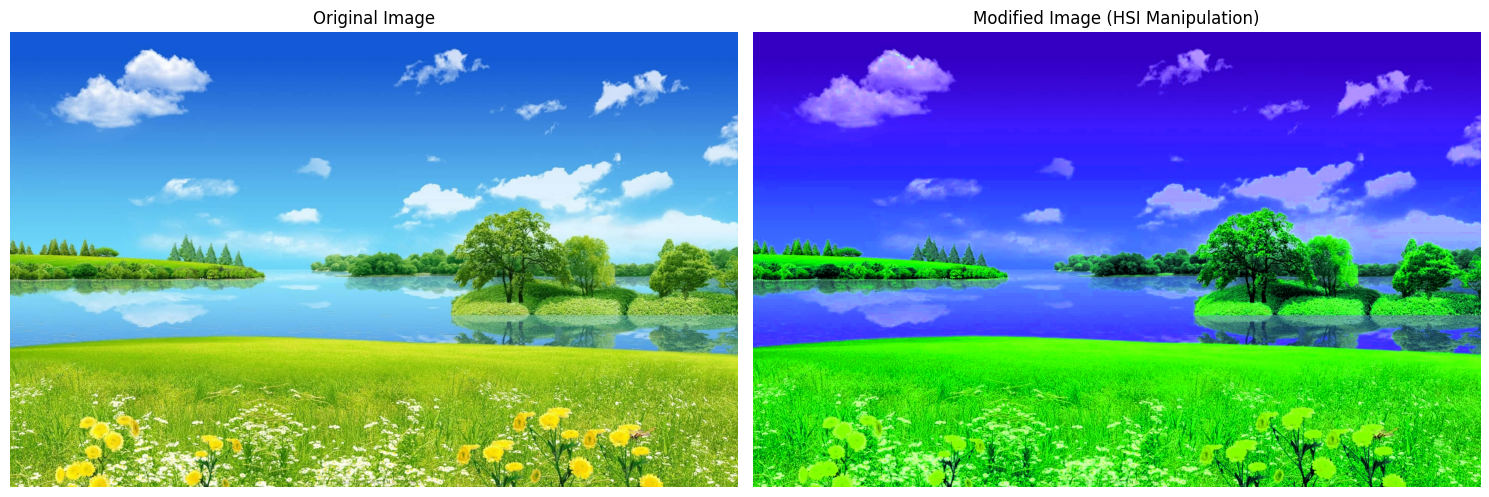

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load an image
image = cv2.imread('color.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

# Function to convert RGB to HSI
def rgb_to_hsi(image):
    image = image.astype('float32') / 255.0  # Normalize to [0, 1]
    r, g, b = image[:, :, 0], image[:, :, 1], image[:, :, 2]

    # Calculate Intensity (I)
    I = (r + g + b) / 3.0

    # Calculate Saturation (S)
    min_rgb = np.minimum(np.minimum(r, g), b)
    S = 1 - (3 / (r + g + b + 1e-6)) * min_rgb

    # Calculate Hue (H)
    numerator = 0.5 * ((r - g) + (r - b))
    denominator = np.sqrt((r - g)**2 + (r - b) * (g - b))
    H = np.arccos(numerator / (denominator + 1e-6))
    H[b > g] = 2 * np.pi - H[b > g]
    H = H / (2 * np.pi)

    # Stack HSI channels
    HSI = np.dstack((H, S, I))
    return HSI

# Function to convert HSI to RGB
def hsi_to_rgb(hsi):
    H, S, I = hsi[:, :, 0], hsi[:, :, 1], hsi[:, :, 2]
    H = H * 2 * np.pi  # Rescale Hue to [0, 2π]

    # Initialize RGB channels
    R = np.zeros_like(H)
    G = np.zeros_like(H)
    B = np.zeros_like(H)

    # Case 1: H ∈ [0, 2π/3)
    case1 = (H < 2 * np.pi / 3)
    B[case1] = I[case1] * (1 - S[case1])
    R[case1] = I[case1] * (1 + (S[case1] * np.cos(H[case1]) / np.cos(np.pi / 3 - H[case1])))
    G[case1] = 3 * I[case1] - (R[case1] + B[case1])

    # Case 2: H ∈ [2π/3, 4π/3)
    case2 = (H >= 2 * np.pi / 3) & (H < 4 * np.pi / 3)
    H[case2] = H[case2] - 2 * np.pi / 3
    R[case2] = I[case2] * (1 - S[case2])
    G[case2] = I[case2] * (1 + (S[case2] * np.cos(H[case2]) / np.cos(np.pi / 3 - H[case2])))
    B[case2] = 3 * I[case2] - (R[case2] + G[case2])

    # Case 3: H ∈ [4π/3, 2π)
    case3 = (H >= 4 * np.pi / 3)
    H[case3] = H[case3] - 4 * np.pi / 3
    G[case3] = I[case3] * (1 - S[case3])
    B[case3] = I[case3] * (1 + (S[case3] * np.cos(H[case3]) / np.cos(np.pi / 3 - H[case3])))
    R[case3] = 3 * I[case3] - (G[case3] + B[case3])

    # Clip values to [0, 1] and scale to [0, 255]
    RGB = np.dstack((R, G, B))
    RGB = np.clip(RGB, 0, 1) * 255
    RGB = RGB.astype('uint8')
    return RGB

# Convert RGB to HSI
hsi_image = rgb_to_hsi(image)

# Manipulate HSI components
# Example: Increase Hue by 0.1, Increase Saturation by 0.2, Decrease Intensity by 0.1
hsi_image[:, :, 0] = (hsi_image[:, :, 0] + 0.1) % 1.0  # Hue manipulation (cyclic)
hsi_image[:, :, 1] = np.clip(hsi_image[:, :, 1] + 0.2, 0, 1)  # Saturation manipulation
hsi_image[:, :, 2] = np.clip(hsi_image[:, :, 2] - 0.1, 0, 1)  # Intensity manipulation

# Convert HSI back to RGB
modified_image = hsi_to_rgb(hsi_image)

# Display the original and modified images
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(modified_image)
plt.title('Modified Image (HSI Manipulation)')
plt.axis('off')

plt.tight_layout()
plt.show()

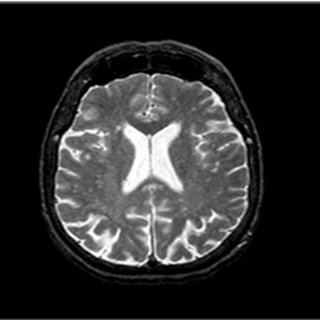

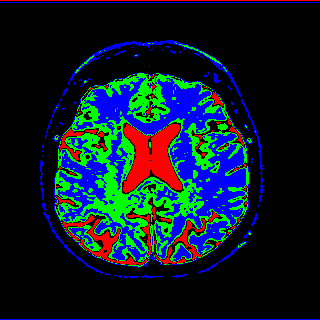

In [3]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow  # Import for Colab

# Load the grayscale image
image = cv2.imread("brain_mri.jpg", cv2.IMREAD_GRAYSCALE)

# Define an empty color image
pseudo_color = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)

# Apply intensity slicing and assign colors
pseudo_color[(image >= 50) & (image < 100)] = [255, 0, 0]   # Blue
pseudo_color[(image >= 100) & (image < 150)] = [0, 255, 0]  # Green
pseudo_color[(image >= 200) & (image <= 255)] = [0, 0, 255] # Red

# Display images using cv2_imshow() in Colab
cv2_imshow(image)
cv2_imshow(pseudo_color)